In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from IPython.display import HTML

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
IMAGE_SIZE=256
CHANNELS=3
BATCH_SIZE=32

train_datagen=ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=10

)
train_generator=train_datagen.flow_from_directory(
    'dataset/Train',
    target_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size=32,
    class_mode='sparse',
    
    
)



Found 1898 images belonging to 3 classes.


In [3]:
for image_batch, label_batch in train_generator:
   print(image_batch[0])
   break


[[[0.6847357  0.64892864 0.6528502 ]
  [0.6867042  0.65141004 0.6553316 ]
  [0.68867266 0.6533785  0.65730006]
  ...
  [0.8270486  0.80744076 0.82312703]
  [0.84477055 0.8251627  0.840849  ]
  [0.86751056 0.8479027  0.863589  ]]

 [[0.6763405  0.63712484 0.6410464 ]
  [0.6751053  0.6360881  0.64000964]
  [0.6770738  0.63871276 0.64263433]
  ...
  [0.8287199  0.8091121  0.82479835]
  [0.84824985 0.828642   0.8443283 ]
  [0.8692994  0.84969157 0.86537784]]

 [[0.69341516 0.65339476 0.6585235 ]
  [0.689181   0.64996535 0.6538869 ]
  [0.6865564  0.6473407  0.6512623 ]
  ...
  [0.83200073 0.8123929  0.82807916]
  [0.8521868  0.83257896 0.84826523]
  [0.86339396 0.8437861  0.8594724 ]]

 ...

 [[0.55838627 0.51132745 0.5191706 ]
  [0.5669182  0.5198594  0.5277025 ]
  [0.5656159  0.5185571  0.5264002 ]
  ...
  [0.57521445 0.55168504 0.5673713 ]
  [0.581776   0.5582466  0.5739329 ]
  [0.58189946 0.55837005 0.5740563 ]]

 [[0.5603547  0.5132959  0.521139  ]
  [0.5682305  0.5211717  0.5290148 ]


In [4]:
validation_datagen=ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    horizontal_flip=True
)
validation_generator=validation_datagen.flow_from_directory(
    'dataset/val',
    target_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size=32,
    class_mode='sparse',
    
    
)

Found 237 images belonging to 3 classes.


In [5]:
test_datagen=ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    horizontal_flip=True
)
test_generator=validation_datagen.flow_from_directory(
    'dataset/test',
    target_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size=32,
    class_mode='sparse',
    
    
)

Found 488 images belonging to 3 classes.


In [6]:
resize_and_rescale = tf.keras.Sequential([
    layers.experimental.preprocessing.Resizing(IMAGE_SIZE,IMAGE_SIZE),
    layers.experimental.preprocessing.Rescaling(1./255)
])


In [7]:
input_shape=(BATCH_SIZE,IMAGE_SIZE,IMAGE_SIZE,CHANNELS)
n_classes=3
model = models.Sequential([
    resize_and_rescale,
    layers.InputLayer(input_shape=input_shape),
    layers.Conv2D(32, kernel_size = (3,3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])
model.build(input_shape=input_shape)



In [8]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (32, 256, 256, 3)         0         
                                                                 
 input_1 (InputLayer)        multiple                  0         
                                                                 
 conv2d (Conv2D)             (32, 254, 254, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (32, 127, 127, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (32, 125, 125, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (32, 62, 62, 64)          0         
 g2D)                                                 

In [9]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)
    

In [16]:
1898/32


59.3125

In [10]:
237/32


7.40625

In [12]:
history =model.fit(
    train_generator,
    steps_per_epoch=59,
    batch_size=32,
    validation_data=validation_generator,
    validation_steps=7,
    verbose=1,
    epochs=20
)


Epoch 1/20
59/59 [==============================] - 120s 2s/step - loss: 1.0976 - accuracy: 0.3558 - val_loss: 1.1018 - val_accuracy: 0.3304
Epoch 2/20
59/59 [==============================] - 107s 2s/step - loss: 1.0962 - accuracy: 0.3708 - val_loss: 1.1036 - val_accuracy: 0.3170
Epoch 3/20
59/59 [==============================] - 97s 2s/step - loss: 1.0961 - accuracy: 0.3687 - val_loss: 1.1003 - val_accuracy: 0.3348
Epoch 4/20
59/59 [==============================] - 102s 2s/step - loss: 1.0957 - accuracy: 0.3714 - val_loss: 1.1029 - val_accuracy: 0.3259
Epoch 5/20
59/59 [==============================] - 108s 2s/step - loss: 1.0959 - accuracy: 0.3708 - val_loss: 1.1024 - val_accuracy: 0.3170
Epoch 6/20
59/59 [==============================] - 117s 2s/step - loss: 1.0958 - accuracy: 0.3698 - val_loss: 1.1034 - val_accuracy: 0.3125
Epoch 7/20
59/59 [==============================] - 92s 2s/step - loss: 1.0957 - accuracy: 0.3676 - val_loss: 1.1018 - val_accuracy: 0.3259
Epoch 8/20
59/5

In [13]:
scores=model.evaluate(test_generator)


16/16 [==============================] - 15s 920ms/step - loss: 1.1033 - accuracy: 0.3197


In [14]:
scores


[1.1032907962799072, 0.3196721374988556]

In [15]:
history

In [16]:
history.params

{'verbose': 1, 'epochs': 20, 'steps': 59}

In [17]:
history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

In [18]:
acc=history.history['accuracy']
val_acc =history.history['val_accuracy']

loss=history.history['loss']
val_loss=history.history['val_loss']

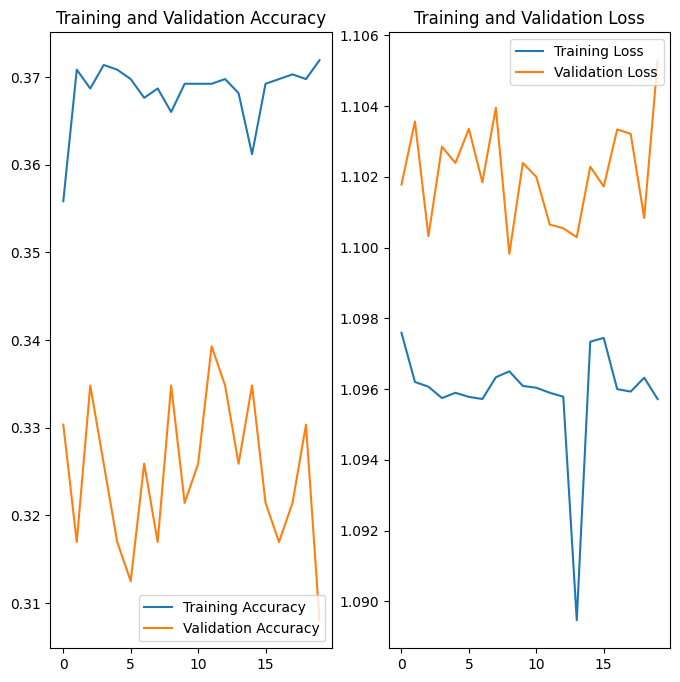

In [20]:
EPOCHS=20
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')


plt.subplot(1,2,2)
plt.plot(range(EPOCHS),loss,label='Training Loss')
plt.plot(range(EPOCHS),val_loss,label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()


First image to predict


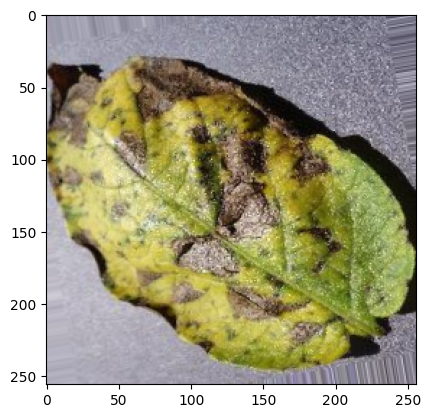

Actual label: Potato___Early_blight
1/1 [==============================] - 1s 819ms/step
Predicted label: Potato___Early_blight


In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Add this line
class_names = list(test_generator.class_indices.keys())

for images_batch, labels_batch in test_generator:
    first_image = images_batch[0]
    first_label = int(labels_batch[0])

    print("First image to predict")
    plt.imshow(first_image)
    plt.show()

    print("Actual label:", class_names[first_label])

    batch_prediction = model.predict(images_batch)
    print("Predicted label:", class_names[np.argmax(batch_prediction[0])])

    break   # stop after first batch

In [23]:
def predict(model,img):
    img_array=tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array=tf.expand_dims(img_array,0)

    predictions=model.predict(img_array)

    predicted_class=class_names[np.argmax(predictions[0])]
    confidence = round(100*(np.max(predictions[0])),2)
    return predicted_class,confidence

In [29]:
import numpy as np
import tensorflow as tf

def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(img)  # ✅ use img
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * np.max(predictions[0]), 2)

    return predicted_class, confidence

1/1 [==============================] - 0s 69ms/step


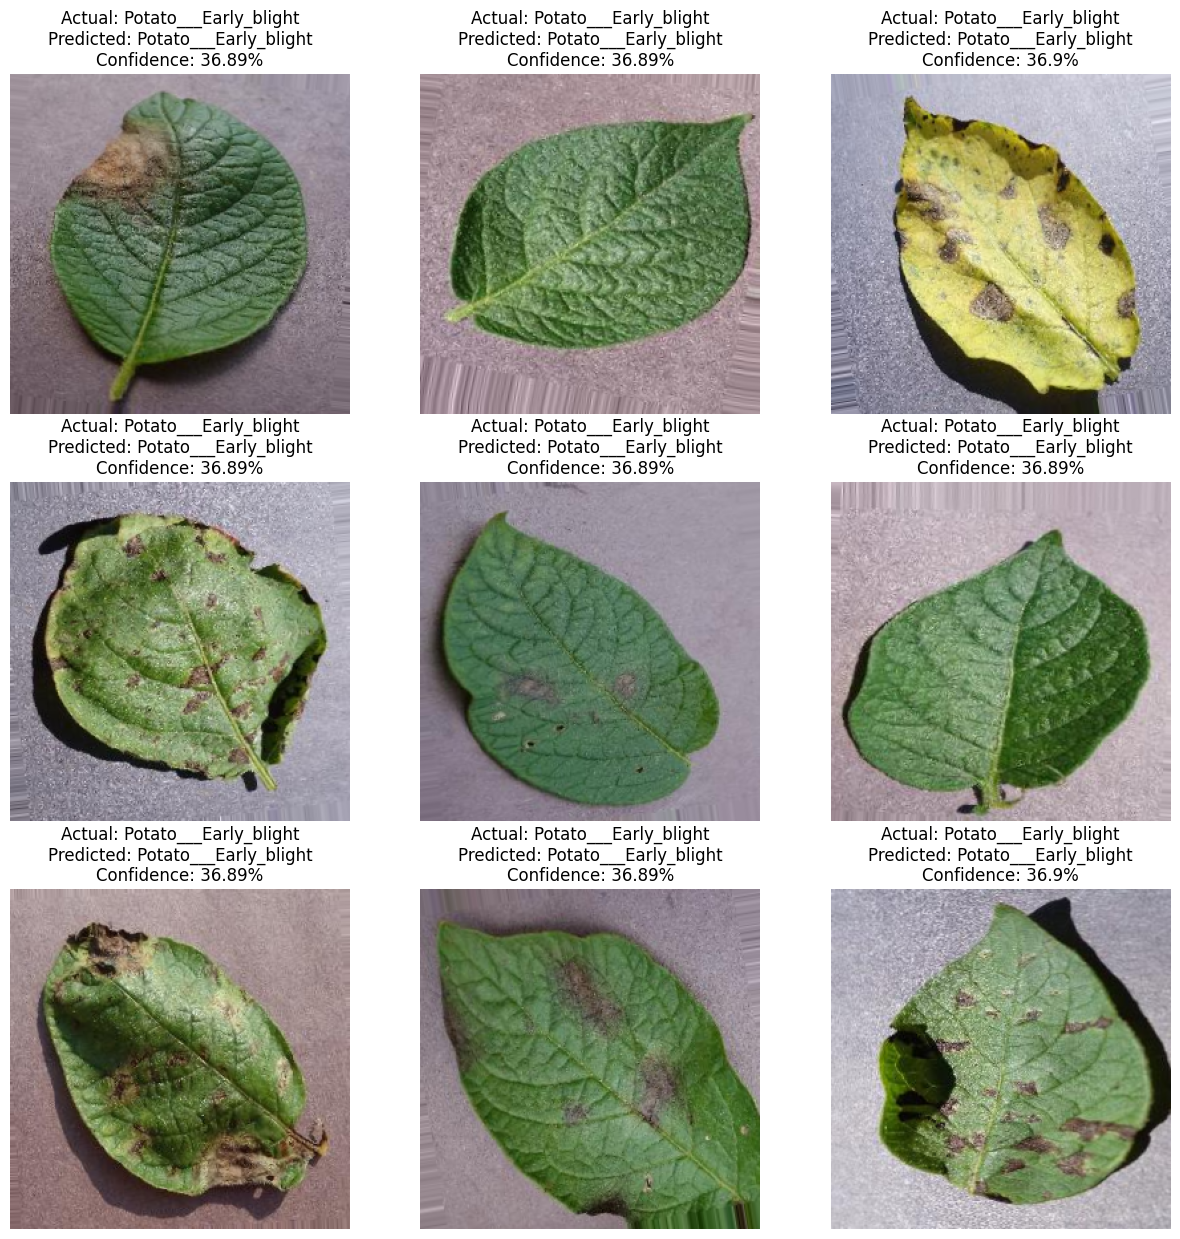

In [30]:
plt.figure(figsize=(15,15))

for images, labels in test_generator:
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i])

        predicted_class, confidence = predict(model, images[i])
        actual_class = class_names[np.argmax(labels[i])]

        plt.title(f"Actual: {actual_class}\nPredicted: {predicted_class}\nConfidence: {confidence}%")
        plt.axis("off")

    break

In [31]:
model.save("../potatoes.h5")

C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
